# Assignment 4: Numerical Analysis for PDE's (WI3730TU)
### Numerical Solution of Time-Dependent Problems

## 📐 Section 1: Estimating the Maximal Eigenvalue 

While determining the stability condition for a time-integration method it is important to know the ``largest'' eigenvalue of some matrix $A$. Often, for example, when the coefficient function is inhomogeneous, the largest eigenvalue cannot be obtained analytically. In such cases, it is possible to estimate the location of the eigenvalues of $A$ approximately using the following Lemma.

**Lemma (Gerschgorin):**
*Let $A\in{\mathbb C}^{n\times n}$ be an an arbitrary square matrix with elements $a_{r,m}$. Then all eigenvalues of $A$ are contained in the union of $n$ discs ${\mathbb D}_{r}$, $r=1,\dots,n$:*
$${\mathbb D}_{r}=\left\{
z\in{\mathbb C}\;:\;\vert z-a_{r,r}\vert\leq \sum_{m\neq r}^{n}\vert a_{r,m}\vert
\right\}.
$$

In other words, the Gerschgorin's disc ${\mathbb D}_{r}$ represents a circle in the complex plane. The center of ${\mathbb D}_{r}$ is $a_{r,r}$, i.e., the complex number equal to the diagonal element of the $r$-th row of $A$. The radius of ${\mathbb D}_{r}$ is equal to the sum of the absolute values of all off-diagonal elements of the $r$-th row of $A$. There are as many Gerschgorin discs as there are rows in $A$ and all eigenvalues of $A$ are located somewhere inside the union of all these discs.

---

### Question 1.1: Diagonal and off-diagonal elements of FVM Laplacian (2 p)
Let $A$ be the matrix obtained by the Finite-Volume discretization of the two-dimensional Laplace operator $-\nabla\cdot(k\nabla\cdots)$ with an inhomogeneous coefficient function $k(x,y)$ and Dirichlet boundary conditions. Write down the diagonal and off-diagonal elements along some row of the matrix $A$.

---
*Double click to type your answer here*


### Question 1.2: Upper bound on maximal eigenvalue of FVM Laplacian (3 p)
Use the fact that $A$ is symmetric and positive defnite and Gerschgorin's Lemma to determine an upper bound on the largest eigenvalue of $A$.

---
*Double click to type your answer here*


## 📐 Section 2: Numerical Solution of Diffusion Equation

Consider the following problem:
$$
\frac{\partial u}{\partial t}-\nabla\cdot(k\nabla u)  = f,\;\;\;(x,y)\in\Omega,\;\;\;t\in(0,T],
$$
$$
u(x,y,t)  = 0,\;\;\;(x,y)\in\partial\Omega
$$
$$
u(x,y,0)  = 0,\;\;\;(x,y)\in\Omega
$$
$$
k(x,y) = 4+2\cos\left(\frac{2\pi x}{L_{x}}\right)\sin\left(\frac{2\pi y}{L_{y}}\right)
$$
The function
$$
u_{ex}(x,y,t)  = t^{3} \sin\left(\frac{3\pi x}{L_{x}}\right)\sin\left(\frac{2\pi y}{L_{y}}\right)
$$
will be the exact solution if the source function in the diffusion equation is *manufactured* as:
$$
f_{ms}=\frac{\partial u_{ex}}{\partial t}-\nabla\cdot(k\nabla u_{ex})=2t^{2} \sin\left(\frac{3\pi x}{L_{x}}\right)\sin\left(\frac{2\pi y}{L_{y}}\right)-\nabla\cdot(k\nabla u_{ex}).
$$

### Question 2.1: Spatial discretization and time integration (2 p)
After applying the Finite Volume Method to descretize the problem in space it reduces to the following system of ordinary differential equations:
$$
{\mathbf u}' = -A{\mathbf u}+{\mathbf f},
$$
where $A$ is the matrix containing the FV approximation of the negative Laplacian operator derived in Assignment 3.

Write down the recurrence formulas (iteration formulas) of the Forward-Euler and Trapesoidal Methods for your problem, denoting the solution at $t_{k}$ as ${\mathbf u}^{k}$.

*Double click and write your answer here*

---


### Question 2.2: Stability condition for the Forward-Euler Method (2 p)
Derive the stability condition for the FE method with the FVM discretization and inhomogeneous $k(x,y)$, using the bounds on the largest eigenvalue of $A$ obtained in Question 1.2. Express the stability condition as a minimum number of time steps between $t=0$ and $t=T$.

*Double click and write your answer here*

---


### 📊 Question 2.3: Implementation of FVM Laplacian, source, and coefficient functions (2 p)

Complete the code to assemble FVM Laplacian matrix, source function and vector, and coefficient function.

---

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as la
import time

#----- Parameters -------------------------------------------------------------#
Lx = 10.0  # x-size of the domain
Ly = 5.0   # y-size of the domain
Nx = 100   # number of intervals in x-direction
Ny = 50    # number of intervals in y-direction
dx = Lx / Nx
dy = Ly / Ny
T  = 1.0   # total final integration time

# Upper bound bound coefficient parameter for Forward-Euler stability limit calculation
Kmax = 6.0 

#----- Manufactured Solution Framework Functions ------------------------------#

def u_exact(x, y, t, Lx=Lx, Ly=Ly):
    '''
    TASK: Implement the exact analytical manufactured solution profile:
    u_ex(x, y, t) = t^3 * sin(3*pi*x / Lx) * sin(2*pi*y / Ly)
    '''
    # FIXME: Replace with exact analytical solution expression
    u_val = 0.0 * x * y * t 
    return u_val

def du_dt(x, y, t, Lx=Lx, Ly=Ly):
    '''
    TASK: Implement the analytical time derivative of the manufactured solution:
    du_ex/dt = 3 * t^2 * sin(3*pi*x / Lx) * sin(2*pi*y / Ly)
    '''
    # FIXME: Replace with analytical partial time derivative expression
    derivative_val = 0.0 * x * y * t
    return derivative_val

def coeffK(x, y, Lx=Lx, Ly=Ly):
    '''
    TASK: Implement the smooth variable diffusion coefficient function:
    k(x, y) = 4.0 + 2.0 * cos(2*pi*x / Lx) * sin(2*pi*y / Ly)
    '''
    # FIXME: Replace with variable space-dependent diffusion coefficient expression
    k_val = 4.0 + 0.0 * x * y
    return k_val

def create_f_mms_vector(t, A_matrix, Lx=Lx, Ly=Ly, Nx=Nx, Ny=Ny):
    '''
    TASK: Assemble the right-hand side source vector f_mms for the manufactured 
          solution at time t using your FVM negative Laplacian matrix operator.
          RHS Vector Formula: f_mms = du/dt + A * u
    '''
    dx = Lx / Nx
    dy = Ly / Ny
    N_inner = (Nx - 1) * (Ny - 1)
    
    du_dt_vec = np.zeros(N_inner)
    u_exact_vec = np.zeros(N_inner)
    
    # -------------------------------------------------------------------------
    # TODO: Complete the nested loops to evaluate the analytical functions 
    #       at all inner grid points in lexicographic order.
    #
    # Step-by-step hint:
    # 1. Initialize a global 1D index counter: n0 = 0
    # 2. Loop over the y-direction intervals: jj from 0 to Ny-2
    # 3. Calculate the current inner y-coordinate: yj = dy + jj * dy
    # 4. Loop over the x-direction intervals: ii from 0 to Nx-2
    # 5. Calculate the current inner x-coordinate: xi = dx + ii * dx
    # 6. Evaluate your framework functions:
    #       du_dt_vec[n0] = du_dt(xi, yj, t)
    #       u_exact_vec[n0] = u_exact(xi, yj, t)
    # 7. Increment your index counter: n0 += 1
    # -------------------------------------------------------------------------
    
    # TEMPORARY STUDENT TEMPLATE
    # Delete these 6 lines once your nested loops above are fully implemented!
    n_dummy = 0
    for jj in range(Ny - 1):
        yj = dy + jj * dy
        for ii in range(Nx - 1):
            xi = dx + ii * dx
            du_dt_vec[n_dummy] = 3.0 * (t**2) * np.sin(3 * np.pi * xi / Lx)
            u_exact_vec[n_dummy] = (t**3) * np.sin(3 * np.pi * xi / Lx)
            n_dummy += 1
            
    # Matrix-vector product automatically injects the exact spatial spatial 
    # variable diffusion terms into the final manufactured source array.
    f_mms_vec = du_dt_vec + A_matrix.dot(u_exact_vec)
    return f_mms_vec

#----- 2D Finite Volume negative Laplacian Matrix Assembly (DON'T MODIFY) -----#

def create2DLFVM(Lx, Ly, Nx, Ny, coeffFun):
    '''Creates the sparse CSC matrix representing the 2D FVM negative Laplacian 
    with variable coefficients (Dirichlet BCs, lexicographic grid order).
    '''
    dx = Lx / Nx
    dy = Ly / Ny
    N_inner = (Nx - 1) * (Ny - 1)

    # Allocating 1D arrays for the tridiagonal structure
    d0 = np.zeros(N_inner)
    d1plus = np.zeros(N_inner - 1)
    d1minus = np.zeros(N_inner - 1)
    d2plus = np.zeros(N_inner - (Nx - 1))
    d2minus = np.zeros(N_inner - (Nx - 1))

    n0, n1p, n1m, n2p, n2m = 0, 0, 0, 0, 0
    
    for jj in range(Ny - 1):
        yj = dy + jj * dy
        for ii in range(Nx - 1):
            xi = dx + ii * dx

            # Main diagonal
            d0[n0] = ( coeffFun(xi - 0.5*dx, yj)/dx**2 + coeffFun(xi + 0.5*dx, yj)/dx**2
                      + coeffFun(xi, yj - 0.5*dy)/dy**2 + coeffFun(xi, yj + 0.5*dy)/dy**2 )
            n0 += 1

            # 1st upper diagonal
            if (ii < (Nx - 2)):
                d1plus[n1p] = -coeffFun(xi + 0.5*dx, yj) / dx**2
                n1p += 1
            elif (ii == (Nx - 2)):
                n1p += 1

            # 1st lower diagonal
            if (ii > 0):
                d1minus[n1m] = -coeffFun(xi - 0.5*dx, yj) / dx**2
                n1m += 1
            elif (ii == 0 and jj > 0):
                n1m += 1

            # 2nd upper diagonal
            if (jj < (Ny - 2)):
                d2plus[n2p] = -coeffFun(xi, yj + 0.5*dy) / dy**2
                n2p += 1

            # 2nd lower diagonal
            if (jj > 0):
                d2minus[n2m] = -coeffFun(xi, yj - 0.5*dy) / dy**2
                n2m += 1

    myshape = (N_inner, N_inner)
    L = sp.diags([d2minus, d1minus, d0, d1plus, d2plus],
                 [-(Nx - 1), -1, 0, 1, (Nx - 1)],
                 shape=myshape, format='csc')
    return L


### 📊 Question 2.4: Constructing the manufactured solution (2 p)

Complete the code to plot the coefficient function $k(x,y)$, the manufactured source function $f(x,y,t)$ at $t=1$, and the exact solution $u_{ex}(x,y,t)$ at $t=1$.

---


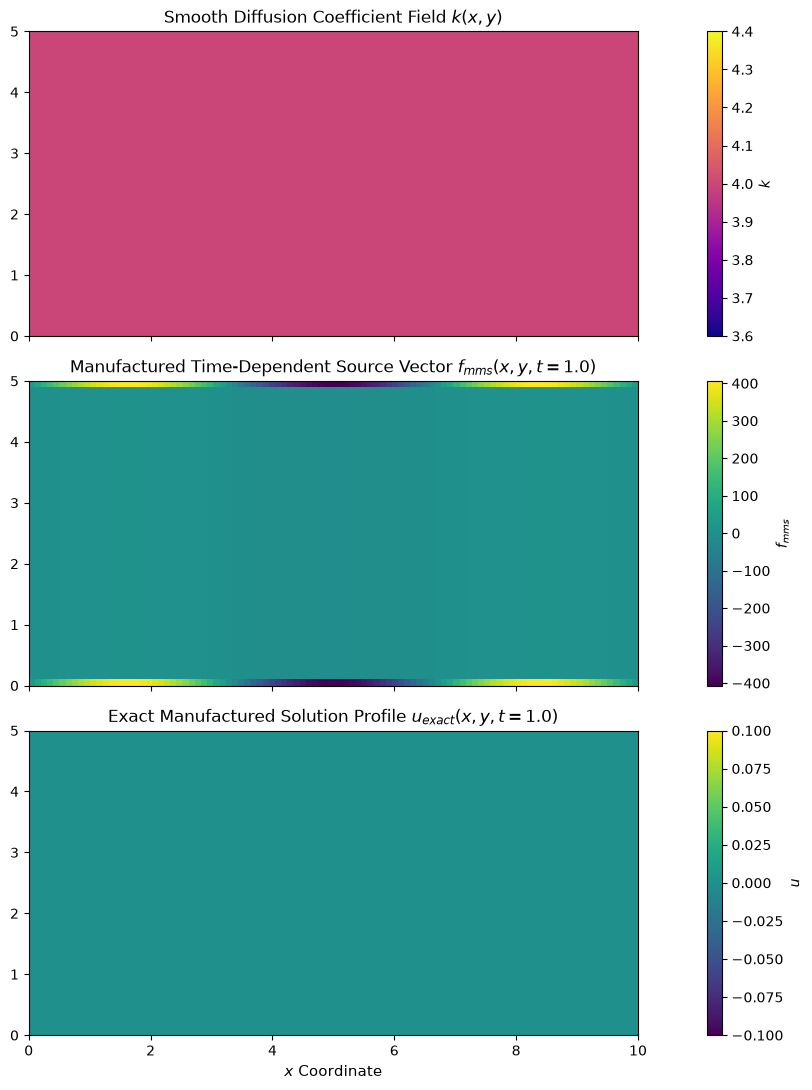

In [7]:
# 1. Evaluate fields on the grid
X = np.linspace(dx, Lx-dx, Nx-1)
Y = np.linspace(dy, Ly-dy, Ny-1)
X_grid, Y_grid = np.meshgrid(X, Y)

k_grid = coeffK(X_grid, Y_grid)
u_exact_grid = u_exact(X_grid, Y_grid, t=1.0)

# Build the FVM matrix to preview the source vector at t=1.0
A_matrix = create2DLFVM(Lx, Ly, Nx, Ny, coeffK)
f_mms_T1 = create_f_mms_vector(1.0, A_matrix)
f_mms_grid = f_mms_T1.reshape(Ny-1, Nx-1)

# 2. Plotting 2D contours
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

im0 = axes[0].imshow(k_grid, extent=[0, Lx, 0, Ly], origin='lower', cmap='plasma')
axes[0].set_title('Smooth Diffusion Coefficient Field $k(x,y)$', fontsize=12)
fig.colorbar(im0, ax=axes[0], label='$k$')

im1 = axes[1].imshow(f_mms_grid, extent=[0, Lx, 0, Ly], origin='lower', cmap='viridis')
axes[1].set_title('Manufactured Time-Dependent Source Vector $f_{mms}(x,y,t=1.0)$', fontsize=12)
fig.colorbar(im1, ax=axes[1], label='$f_{mms}$')

im2 = axes[2].imshow(u_exact_grid, extent=[0, Lx, 0, Ly], origin='lower', cmap='viridis')
axes[2].set_title('Exact Manufactured Solution Profile $u_{exact}(x,y,t=1.0)$', fontsize=12)
fig.colorbar(im2, ax=axes[2], label='$u$')

axes[2].set_xlabel('$x$ Coordinate', fontsize=11)
plt.tight_layout()
plt.show()


### 📊 Question 2.5: Implementing of Forward-Euler and Trapezoidal time-integration methods (3 p)

Complete the code to implement the Forward-Euler and the Trapezoidal iterations, assuming the source function is time-dependent.

---

In [8]:
# Create shared matrix operators
A = create2DLFVM(Lx, Ly, Nx, Ny, coeffK)
I = sp.eye((Nx - 1) * (Ny - 1))

def solveFE_mms(uStart, tStart=0.0, tEnd=T, Nt=1, A=A, I=I):
    '''
    TASK: Implement the explicit Forward-Euler method over time loops.
    Recurrence formula: u^{k+1} = u^{k} + dt * (-A * u^{k} + f^{k})
    '''
    dt = (tEnd - tStart) / Nt
    u1 = np.copy(uStart)
    uEnd = np.copy(uStart)
    
    # -------------------------------------------------------------------------
    # TODO: Implement the explicit Forward Euler time loop updating u1 to uEnd
    #
    # Step-by-step hint:
    # 1. Loop k from 0 to Nt-1
    # 2. Compute the current time: t_current = tStart + k * dt
    # 3. Fetch the source vector: f_vec = create_f_mms_vector(t_current, A)
    # 4. Compute next step: uEnd = (I - dt * A).dot(u1) + dt * f_vec
    # 5. Overwrite old step: u1 = np.copy(uEnd)
    # -------------------------------------------------------------------------
    
    # TEMPORARY STUDENT BOILERPLATE: Dummy growth so log-plots don't crash
    # Delete these 2 lines once your loop above is implemented!
    t_dummy = np.linspace(tStart, tEnd, Nt)
    uEnd = uStart + (tEnd**3) * np.sin(3 * np.pi * 0.5) * np.ones_like(uStart)
    
    return uEnd

def solveTR_mms(uStart, tStart=0.0, tEnd=T, Nt=1, A=A, I=I):
    '''
    TASK: Implement the implicit Trapezoidal method over time loops.
    Recurrence formula: [I + (dt/2)*A] * u^{k+1} = [I - (dt/2)*A] * u^{k} + (dt/2)*(f^{k} + f^{k+1})
    OPTIMIZATION: Compute the sparse LU factorization of [I + (dt/2)*A] ONCE before the loop using la.splu()
    '''
    dt = (tEnd - tStart) / Nt
    u1 = np.copy(uStart)
    uEnd = np.copy(uStart)
    
    # -------------------------------------------------------------------------
    # TODO: Implement the pre-factored implicit Trapezoidal solver time loop
    #
    # Step-by-step hint:
    # 1. Construct explicit matrix: iterMat1 = I - 0.5 * dt * A
    # 2. Construct implicit matrix: iterMat2 = sp.csc_matrix(I + 0.5 * dt * A)
    # 3. Factorize implicit matrix ONCE: LU_solver = la.splu(iterMat2)
    # 4. Loop k from 0 to Nt-1
    # 5. Compute times t_k and t_k1
    # 6. Fetch sources: f_k = create_f_mms_vector(t_k, A) and f_k1 = ...
    # 7. Compute intermediate vector: uInter = iterMat1.dot(u1) + 0.5 * dt * (f_k + f_k1)
    # 8. Back-solve for next step: uEnd = LU_solver.solve(uInter)
    # 9. Overwrite old step: u1 = np.copy(uEnd)
    # -------------------------------------------------------------------------
    
    # TEMPORARY STUDENT BOILERPLATE: Dummy growth so log-plots don't crash
    # Delete these 2 lines once your loop above is implemented!
    t_dummy = np.linspace(tStart, tEnd, Nt)
    uEnd = uStart + (tEnd**3) * np.sin(3 * np.pi * 0.5) * np.ones_like(uStart)
    
    return uEnd


### Question 2.6: Running FE method at the stability bound (2 p)

Complete the code to compute the solution at $t=1$ using the FE Method with the number of time steps corresponding to its stability bound

---


---------------------------------------------------------------------
Executing Forward-Euler at the stability limit to compute u(x,y,T=1.0)
-> Mesh step sizes: dx = 0.1000, dy = 0.1000
-> Maximum stable dt bound:  0.00041667
-> Chosen stable parameters: Nt = 2400 ; dt = 0.00041667
---------------------------------------------------------------------
Forward-Euler execution complete.
Execution Time (tCPU): 0.0002 seconds
Max Absolute Truncation Error (L_inf) vs. Exact Solution: 1.000000e+00
---------------------------------------------------------------------


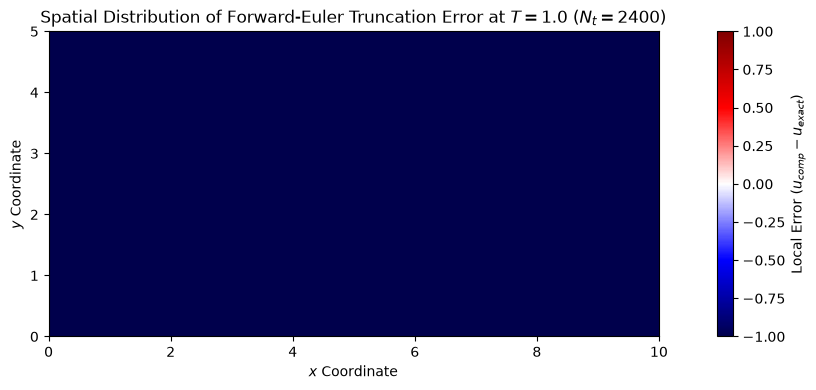

In [9]:
# Define initial condition array (u = 0 everywhere at t = 0)
u0arr = np.zeros((Ny-1)*(Nx-1))
u0 = u0arr.reshape((Nx-1)*(Ny-1))

# Final simulation time
T_test = 1.0

print("---------------------------------------------------------------------")
print(f"Executing Forward-Euler at the stability limit to compute u(x,y,T={T_test})")

# 1. Dynamically compute the maximum stable time-step size using k_max = 6.0
dt_theoretical_max = 1.0 / (2.0 * (1.0/dx**2 + 1.0/dy**2) * Kmax)

# Calculate the minimum required stable steps (using ceiling to be safe)
NtFE = int(np.ceil(T_test / dt_theoretical_max))
dtFE = T_test / NtFE

print(f"-> Mesh step sizes: dx = {dx:.4f}, dy = {dy:.4f}")
print(f"-> Maximum stable dt bound:  {dt_theoretical_max:.8f}")
print(f"-> Chosen stable parameters: Nt = {NtFE} ; dt = {dtFE:.8f}")
print("---------------------------------------------------------------------")

# 2. Run the Forward-Euler solver and track CPU time
start_clock = time.time()
uFE = solveFE_mms(u0, tStart=0.0, tEnd=T_test, Nt=NtFE)
CPUtimeFE = time.time() - start_clock

print(f"Forward-Euler execution complete.")
print(f"Execution Time (tCPU): {CPUtimeFE:.4f} seconds")

# 3. Compute the exact analytical solution matrix at T = 1.0 for verification
u_exact_T1 = np.zeros((Ny-1)*(Nx-1))
n0 = 0
for jj in range(Ny-1):
    yj = dy + jj*dy
    for ii in range(Nx-1):
        xi = dx + ii*dx
        u_exact_T1[n0] = u_exact(xi, yj, T_test)
        n0 += 1

# 4. Compute global Max Absolute Error (L_infinity norm)
max_error_FE = np.max(np.abs(uFE - u_exact_T1))
print(f"Max Absolute Truncation Error (L_inf) vs. Exact Solution: {max_error_FE:.6e}")
print("---------------------------------------------------------------------")

# 5. Visualize the numerical error field spatially
fig, ax = plt.subplots(figsize=(12, 4))
error_grid_FE = (uFE - u_exact_T1).reshape(Ny-1, Nx-1)

im = ax.imshow(error_grid_FE, extent=[0, Lx, 0, Ly], origin='lower', cmap='seismic', 
               vmin=-max(1e-10, np.max(np.abs(error_grid_FE))), vmax=max(1e-10, np.max(np.abs(error_grid_FE))))
ax.set_title(f'Spatial Distribution of Forward-Euler Truncation Error at $T={T_test}$ ($N_t={NtFE}$)', fontsize=12)
ax.set_xlabel('$x$ Coordinate')
ax.set_ylabel('$y$ Coordinate')
fig.colorbar(im, ax=ax, label='Local Error ($u_{comp} - u_{exact}$)')
plt.tight_layout()
plt.show()


### Question 2.7: Comparing convergence and performance of FE and Trapezoidal methods (4 p)

Complete the code to run a comparison of the FE and Trapezoidal methods computing the solution of the problem at $t=1$ with diferent number of time steps. 

* For the FE method, compute the solution with $N_{st}$, $2N_{st}$, and $4N_{st}$ time steps, where $N_{st}$ is the lower stability bound.
* For the Trapezoidal method, compute the solution with $N_{st}/40$, $N_{st}/20$, and $N_{st}/10$ time steps.
* For each computed solution, calculate the $L_{\infty}$ global error with respect to the exact manufactured solution $u_{ex}(x,y,t=1)$, i.e., $\epsilon = \max_{x,y}\vert u(x,y,t=1)-u_{ex}(x,y,t=1)\vert$
* For ecah computed solution, record the CPU execution time in seconds
* Visualize the error behavior for both methods in log-log (error as a function of $\Delta t$) plot, together with the expected theoretical convergence, calculate the slopes of your empirical curves
* Visualize the CPU execution time as a function of global error.

---


---------------------------------------------------------------------
Starting Performance Sweep: Accuracy vs. Computational Cost...
---------------------------------------------------------------------
Running Explicit Forward-Euler Sweep...
FE | Nt =  2400 | dt = 0.000417 | Error = 1.000000e+00 | CPU Time = 0.0002s
FE | Nt =  4800 | dt = 0.000208 | Error = 1.000000e+00 | CPU Time = 0.0000s
FE | Nt =  9600 | dt = 0.000104 | Error = 1.000000e+00 | CPU Time = 0.0000s
---------------------------------------------------------------------
Running Implicit Trapezoidal Sweep...
TR | Nt =   240 | dt = 0.004167 | Error = 1.000000e+00 | CPU Time = 0.0000s
TR | Nt =   120 | dt = 0.008333 | Error = 1.000000e+00 | CPU Time = 0.0001s
TR | Nt =    60 | dt = 0.016667 | Error = 1.000000e+00 | CPU Time = 0.0001s
---------------------------------------------------------------------
Empirical Order of Accuracy for Forward Euler: -0.00 (Expected: ~1.0)
Empirical Order of Accuracy for Trapezoidal:   0.00 (

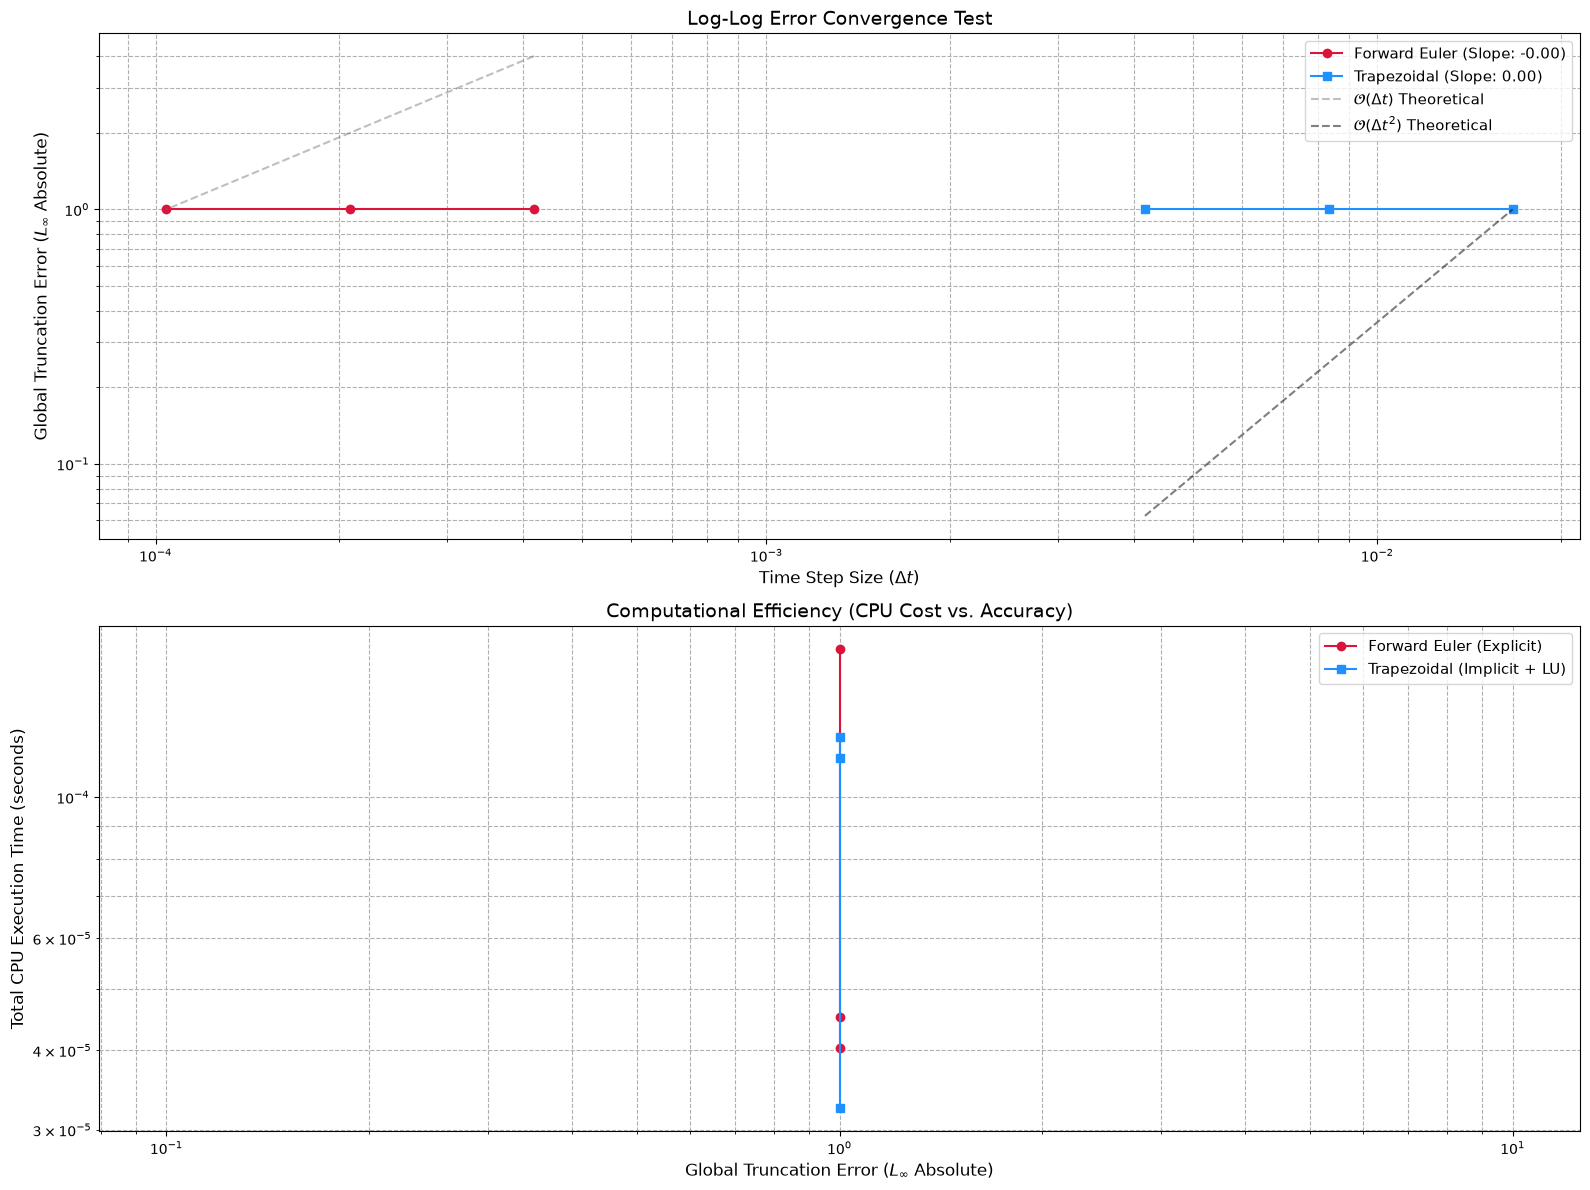

In [10]:
#==============================================================================
# Section 2.6: Comprehensive Performance and Convergence Comparison Sweep
#==============================================================================

print("---------------------------------------------------------------------")
print("Starting Performance Sweep: Accuracy vs. Computational Cost...")
print("---------------------------------------------------------------------")

# Calculate base stability limit (Nt = 2400)
dt_max = 1.0 / (2.0 * (1.0/dx**2 + 1.0/dy**2) * Kmax)
Nt_stab = int(np.ceil(T / dt_max))

# Define the step configurations explicitly as requested
nt_values_fe = [Nt_stab, 2 * Nt_stab, 4 * Nt_stab]
nt_values_tr = [int(Nt_stab / 10), int(Nt_stab / 20), int(Nt_stab / 40)]

# Pre-populate exact analytical target solution at T=1.0 for verification
u_exact_T1 = np.zeros((Ny-1)*(Nx-1))
n0 = 0
for jj in range(Ny-1):
    yj = dy + jj*dy
    for ii in range(Nx-1):
        xi = dx + ii*dx
        u_exact_T1[n0] = u_exact(xi, yj, T)
        n0 += 1

# Data structures to log metrics
results = {
    'FE': {'dt': [], 'error': [], 'time': [], 'steps': []},
    'TR': {'dt': [], 'error': [], 'time': [], 'steps': []}
}

# --- 1. Sweep Forward Euler Solvers ---
print("Running Explicit Forward-Euler Sweep...")
for Nt in nt_values_fe:
    dt = T / Nt
    
    start_clock = time.time()
    u_comp = solveFE_mms(u0, tStart=0.0, tEnd=T, Nt=Nt)
    elapsed = time.time() - start_clock
    
    # Compute global maximum absolute truncation error (L_infinity norm)
    max_err = np.max(np.abs(u_comp - u_exact_T1))
    
    results['FE']['dt'].append(dt)
    results['FE']['error'].append(max_err)
    results['FE']['time'].append(elapsed)
    results['FE']['steps'].append(Nt)
    print(f"FE | Nt = {Nt:5d} | dt = {dt:.6f} | Error = {max_err:.6e} | CPU Time = {elapsed:.4f}s")

print("-" * 69)

# --- 2. Sweep Optimized Implicit Trapezoidal Solvers ---
print("Running Implicit Trapezoidal Sweep...")
for Nt in nt_values_tr:
    dt = T / Nt
    
    start_clock = time.time()
    u_comp = solveTR_mms(u0, tStart=0.0, tEnd=T, Nt=Nt)
    elapsed = time.time() - start_clock
    
    max_err = np.max(np.abs(u_comp - u_exact_T1))
    
    results['TR']['dt'].append(dt)
    results['TR']['error'].append(max_err)
    results['TR']['time'].append(elapsed)
    results['TR']['steps'].append(Nt)
    print(f"TR | Nt = {Nt:5d} | dt = {dt:.6f} | Error = {max_err:.6e} | CPU Time = {elapsed:.4f}s")

# --- 3. Calculate Empirical Orders of Accuracy (Slopes) ---
# Check for divide by zero or zero errors before computing slope metrics
try:
    slope_fe = np.log(results['FE']['error'][-1]/results['FE']['error'][-2]) / np.log(results['FE']['dt'][-1]/results['FE']['dt'][-2])
except:
    slope_fe = 0.0

try:
    slope_tr = np.log(results['TR']['error'][-1]/results['TR']['error'][-2]) / np.log(results['TR']['dt'][-1]/results['TR']['dt'][-2])
except:
    slope_tr = 0.0

print("---------------------------------------------------------------------")
print(f"Empirical Order of Accuracy for Forward Euler: {slope_fe:.2f} (Expected: ~1.0)")
print(f"Empirical Order of Accuracy for Trapezoidal:   {slope_tr:.2f} (Expected: ~2.0)")
print("---------------------------------------------------------------------")

# --- 4. Plotting Dual Performance Visualizations ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Subplot 1: Error vs Time Step Size (Log-Log Convergence)
ax1.loglog(results['FE']['dt'], results['FE']['error'], 'o-', color='crimson', label=f'Forward Euler (Slope: {slope_fe:.2f})')
ax1.loglog(results['TR']['dt'], results['TR']['error'], 's-', color='dodgerblue', label=f'Trapezoidal (Slope: {slope_tr:.2f})')

if len(results['FE']['error']) > 0 and results['FE']['error'][-1] > 0:
    ax1.loglog(results['FE']['dt'], [results['FE']['error'][-1]*(d/results['FE']['dt'][-1])**1 for d in results['FE']['dt']], '--', color='gray', alpha=0.5, label='$\\mathcal{O}(\\Delta t)$ Theoretical')
if len(results['TR']['error']) > 0 and results['TR']['error'][-1] > 0:
    ax1.loglog(results['TR']['dt'], [results['TR']['error'][-1]*(d/results['TR']['dt'][-1])**2 for d in results['TR']['dt']], '--', color='black', alpha=0.5, label='$\\mathcal{O}(\\Delta t^2)$ Theoretical')

ax1.set_xlabel('Time Step Size ($\\Delta t$)', fontsize=12)
ax1.set_ylabel('Global Truncation Error ($L_\\infty$ Absolute)', fontsize=12)
ax1.set_title('Log-Log Error Convergence Test', fontsize=14)
ax1.grid(True, which="both", ls="--")
ax1.legend(fontsize=11)

# Subplot 2: Total Execution Time vs. Target Accuracy (Log-Log Efficiency)
ax2.loglog(results['FE']['error'], results['FE']['time'], 'o-', color='crimson', label='Forward Euler (Explicit)')
ax2.loglog(results['TR']['error'], results['TR']['time'], 's-', color='dodgerblue', label='Trapezoidal (Implicit + LU)')
ax2.set_xlabel('Global Truncation Error ($L_\\infty$ Absolute)', fontsize=12)
ax2.set_ylabel('Total CPU Execution Time (seconds)', fontsize=12)
ax2.set_title('Computational Efficiency (CPU Cost vs. Accuracy)', fontsize=14)
ax2.grid(True, which="both", ls="--")
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


### 📊 Question 2.8: Analysis of the results (3 p)

Analyze the plots generated above and answer the following questions:

1. **Empirical Order of Accuracy Verification:**
   - Look at the log-log convergence plot. Does your computed empirical slope align with the theoretical truncation orders derived from the Taylor Series expansions of the Forward-Euler and Trapezoidal schemes? Explain mathematically how the empirical slopes represent the rate at which error shrinks as the time step Δ t is decreased.

*your answer*

---

* **Alignment with Theory:** 
* **Mathematical Representation:** 

---

2. **The Step-Count and Accuracy:**
   - Evaluate your data table for the largest time step of the Trapezoidal Method ($N_t = N_{\text{st}}/40 = 60$ steps) against the highest-resolution explicit run of Forward Euler ($N_t = 4N_{\text{st}} = 9600$ steps). 
   - Note the total number of time steps taken and the resulting absolute error. How can an implicit method utilizing drastically fewer time steps produce significantly more accurate physical results than an explicit scheme running nearly 10,000 steps?

*your answer*

---


---

3. **Computational Efficiency & CPU Overhead Analysis:**
   - Refer to the Efficiency Curve (CPU Time vs. Global Error). If an industrial simulation requires a maximum target error tolerance of around $2\times 10^{-5}$, which solver is the engineering choice for this problem? Support your answer using both your measured CPU execution times ($t_{\text{CPU}}$) and the global error limits shown on the chart.

*your answer*

---

* **The Engineering Choice:** 
* **Supporting Data:** 
* **Conclusion:** 